**1. Introduction and Dataset Acquisition**

This project implements a Convolutional Neural Network (CNN) for the classification of fish species using the "Large Scale Fish Dataset" from Kaggle. The implementation follows established CNN principles and demonstrates the complete pipeline from data preprocessing to model evaluation.

In [1]:
import kagglehub
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import random
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import confusion_matrix
import seaborn as sns
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import time

# Download the dataset from Kaggle
path = kagglehub.dataset_download("crowww/a-large-scale-fish-dataset")

# Explore dataset structure
print("Dataset contents:")
for entry in os.listdir(path):
    print(entry)

# Define the base path for the fish dataset
dataset_path = Path(path) / "Fish_Dataset" / "Fish_Dataset"

# Extract class labels (excluding ground truth folders marked with 'GT')
classes = [d.name for d in dataset_path.iterdir() if d.is_dir() and not d.name.endswith(" GT")]
print(f"\nNumber of classes: {len(classes)}")
print(f"Classes: {classes}")

/Users/emanuelesmisi/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Dataset contents:
Segmentation_example_script.m
Fish_Dataset
README.txt
NA_Fish_Dataset
license.txt

Number of classes: 9
Classes: ['Sea Bass', 'Red Mullet', 'Gilt-Head Bream', 'Red Sea Bream', 'Shrimp', 'Black Sea Sprat', 'Striped Red Mullet', 'Hourse Mackerel', 'Trout']


**2. Dataset Analysis and Class Distribution**

Before training, it is crucial to analyze the dataset for class imbalance, as this can significantly impact model performance. We compute the Coefficient of Variation (CV) as a statistical measure of imbalance.


=== Dataset Integrity and Balance Analysis ===
Class 'Sea Bass': 1000 images
Class 'Red Mullet': 1000 images
Class 'Gilt-Head Bream': 1000 images
Class 'Red Sea Bream': 1000 images
Class 'Shrimp': 1000 images
Class 'Black Sea Sprat': 1000 images
Class 'Striped Red Mullet': 1000 images
Class 'Hourse Mackerel': 1000 images
Class 'Trout': 1000 images

--- Statistical Summary ---
Mean images per class: 1000.00
Standard deviation: 0.00
Coefficient of Variation (CV): 0.0000
 Dataset is well-balanced


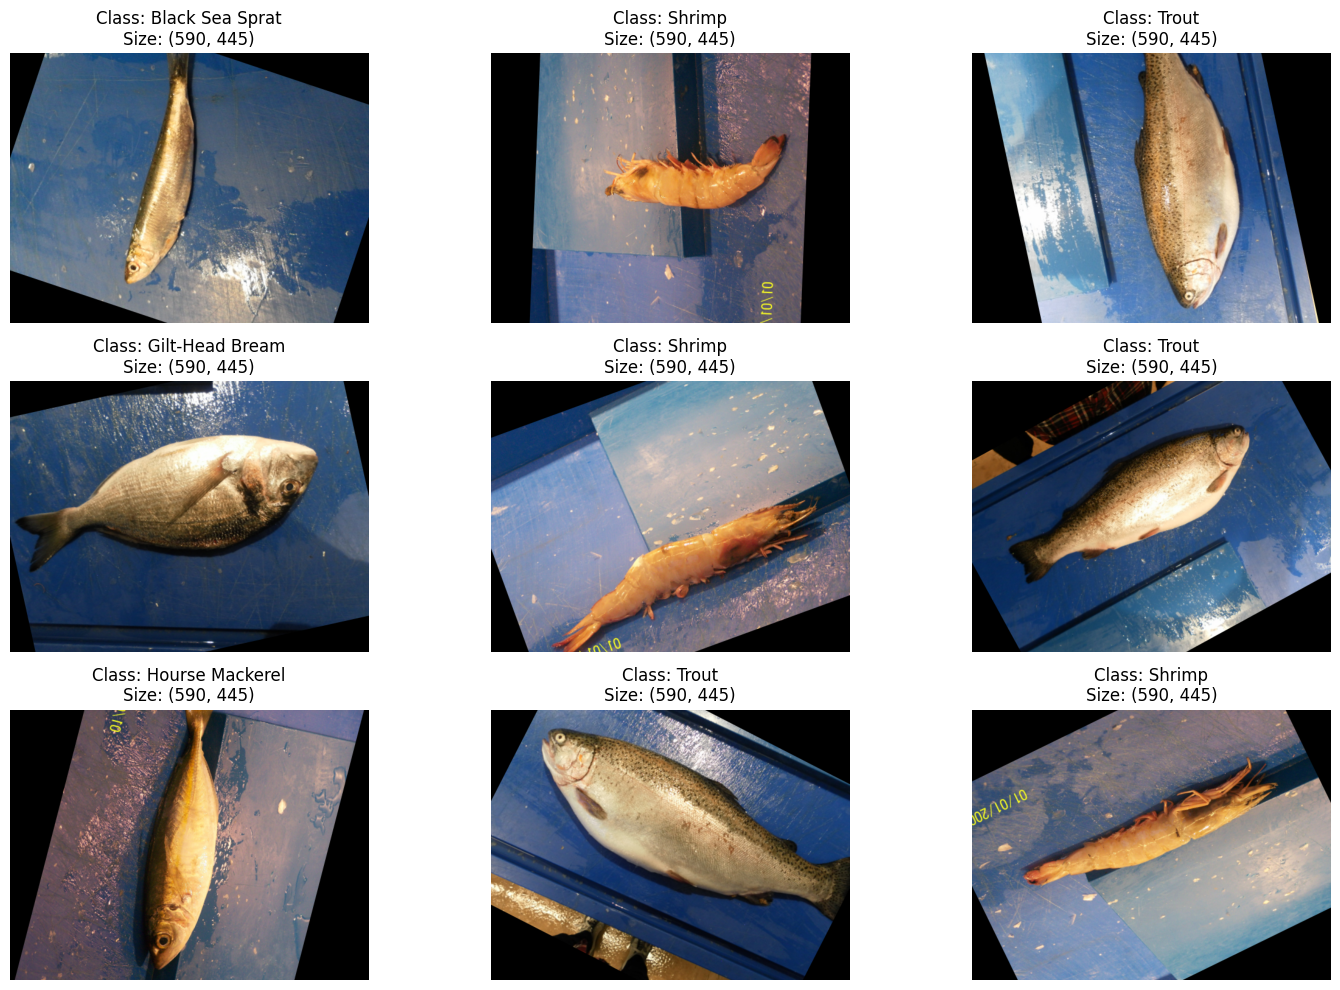

In [3]:
def analyze_dataset_balance(dataset_path, classes):
    """
    Analyzes the distribution of images across classes and detects potential imbalances.
    
    The Coefficient of Variation (CV = σ/μ) quantifies the degree of variability:
    - CV < 0.15: Well-balanced dataset
    - CV > 0.15: Imbalanced dataset (requires special handling)
    
    Args:
        dataset_path: Path to the root dataset directory
        classes: List of class names
    
    Returns:
        valid_image_paths: List of all valid image file paths
        labels: Corresponding class labels for each image
        class_counts: Dictionary mapping class names to image counts
    """
    class_counts = {}
    valid_image_paths = []
    labels = []

    print("\n=== Dataset Integrity and Balance Analysis ===")
    
    for class_name in classes:
        # Navigate to class-specific subdirectory
        class_dir = dataset_path / class_name / class_name 
        
        # Collect all image files (supporting both PNG and JPG formats)
        images = list(class_dir.glob("*.png")) + list(class_dir.glob("*.jpg"))
        count = len(images)
        class_counts[class_name] = count

        print(f"Class '{class_name}': {count} images")

        # Build the complete dataset structure
        for img_path in images:
            valid_image_paths.append(img_path)
            labels.append(class_name)

    # Statistical analysis of class distribution
    counts = list(class_counts.values())
    mean_count = np.mean(counts)
    std_dev = np.std(counts)
    
    # Coefficient of Variation: normalized measure of dispersion
    cv = std_dev / mean_count

    print(f"\n--- Statistical Summary ---")
    print(f"Mean images per class: {mean_count:.2f}")
    print(f"Standard deviation: {std_dev:.2f}")
    print(f"Coefficient of Variation (CV): {cv:.4f}")

    # Imbalance threshold based on literature (Japkowicz & Stephen, 2002)
    if cv > 0.15:
        print(" Dataset is imbalanced (CV > 0.15)")
        print("Recommendation: Consider class weighting or data augmentation")
    else:
        print(" Dataset is well-balanced")
        
    return valid_image_paths, labels, class_counts


def visualize_samples(image_paths, labels, num_samples=9):
    """
    Visualizes a random grid of images from the dataset for qualitative inspection.
    This helps identify potential issues such as mislabeled data or poor image quality.
    
    Args:
        image_paths: List of image file paths
        labels: Corresponding class labels
        num_samples: Number of images to display (default: 9 for 3x3 grid)
    """
    plt.figure(figsize=(15, 10))
    indices = random.sample(range(len(image_paths)), min(num_samples, len(image_paths)))

    for i, idx in enumerate(indices):
        img_path = image_paths[idx]
        label = labels[idx]

        with Image.open(img_path) as img:
            plt.subplot(3, 3, i + 1)
            plt.imshow(img)
            plt.title(f"Class: {label}\nSize: {img.size}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()


# Execute dataset analysis
valid_image_paths, labels, class_counts = analyze_dataset_balance(dataset_path, classes)
visualize_samples(valid_image_paths, labels)

**3. Custom Dataset Implementation**

Following PyTorch best practices, we implement a custom Dataset class that provides fine-grained control over data loading and preprocessing. This approach is superior to generic solutions like ImageFolder as it allows for explicit handling of data transformations and label encoding.

In [7]:
class FishDataset(Dataset):
    """
    Custom PyTorch Dataset for fish species classification.
    
    This implementation provides explicit control over:
    1. Image loading and format conversion (ensuring RGB consistency)
    2. Preprocessing transformations (resizing, normalization)
    3. Label encoding (string class names → integer indices)
    
    Args:
        image_paths: List of paths to image files
        labels: List of string class labels
        class_to_idx: Dictionary mapping class names to integer indices
        transform: Composition of preprocessing transformations
    """
    def __init__(self, image_paths, labels, class_to_idx, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        """Returns the total number of samples in the dataset."""
        return len(self.image_paths)

    def __getitem__(self, idx):
        """
        Retrieves and preprocesses a single sample.
        
        Args:
            idx: Index of the sample to retrieve
        
        Returns:
            image: Preprocessed image tensor of shape [3, H, W]
            label_idx: Integer class label
        """
        img_path = self.image_paths[idx]
        label_name = self.labels[idx]

        # Load image and ensure RGB format (some images might be grayscale or RGBA)
        image = Image.open(img_path).convert("RGB")

        # Apply preprocessing transformations
        if self.transform:
            image = self.transform(image)

        # Convert string label to integer index for loss computation
        label_idx = self.class_to_idx[label_name]

        return image, label_idx

**4. Data Preprocessing and Normalization**

Proper preprocessing is critical for CNN performance. We apply three standard transformations that align with best practices in computer vision:

a)Resizing: Standardizes spatial dimensions for batch processing

b)Tensor Conversion: Converts PIL images to PyTorch tensors with values in [0, 1]

c)Normalization: Centers and scales pixel values to facilitate gradient-based optimization

In [8]:
# Create class-to-index mapping (alphabetically sorted for consistency)
unique_classes = sorted(list(set(labels)))
class_to_idx = {cls_name: i for i, cls_name in enumerate(unique_classes)}

print(f"\nClass encoding: {class_to_idx}")

# Define preprocessing pipeline
# These transformations follow the normalization scheme commonly used in CNNs
# The normalization formula: x_norm = (x - mean) / std
# With mean=std=0.5, this maps [0,1] → [-1,1], improving training stability
preprocess_transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Spatial standardization (trade-off between resolution and memory)
    transforms.ToTensor(),           # Convert to tensor: [H, W, C] → [C, H, W], scale to [0, 1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1, 1]
])

# Instantiate the dataset with preprocessing pipeline
full_dataset = FishDataset(valid_image_paths, labels, class_to_idx, transform=preprocess_transform)

print(f"\nDataset created: {len(full_dataset)} total samples")


Class encoding: {'Black Sea Sprat': 0, 'Gilt-Head Bream': 1, 'Hourse Mackerel': 2, 'Red Mullet': 3, 'Red Sea Bream': 4, 'Sea Bass': 5, 'Shrimp': 6, 'Striped Red Mullet': 7, 'Trout': 8}

Dataset created: 9000 total samples


**5. Train-Test Split and DataLoader Configuration**

We partition the dataset using an 80-20 train-test split, following the standard practice in supervised learning. The DataLoader enables efficient batch processing with automatic shuffling for the training set.

In [9]:
from torch.utils.data import DataLoader, random_split

# Define split ratio (80% training, 20% testing)
# This ratio balances the need for sufficient training data with adequate evaluation data
total_count = len(full_dataset)
train_count = int(0.8 * total_count)
test_count = total_count - train_count

# Perform random split with reproducibility
# Note: For reproducible results, set a seed: torch.manual_seed(42)
train_dataset, test_dataset = random_split(full_dataset, [train_count, test_count])

print(f"\n=== Dataset Split ===")
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples:  {len(test_dataset)}")
print(f"Split ratio: {len(train_dataset)/total_count:.1%} train / {len(test_dataset)/total_count:.1%} test")

# Configure DataLoaders for batch processing
# Batch size is a hyperparameter: larger batches → faster training but higher memory usage
batch_size = 32

# Training DataLoader: shuffle=True ensures randomized batch composition (reduces overfitting)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Testing DataLoader: shuffle=False maintains consistent evaluation order
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nBatch configuration: {batch_size} samples per batch")
print(f"Training batches: {len(train_loader)}")
print(f"Testing batches:  {len(test_loader)}")


=== Dataset Split ===
Training samples: 7200
Testing samples:  1800
Split ratio: 80.0% train / 20.0% test

Batch configuration: 32 samples per batch
Training batches: 225
Testing batches:  57


**6. Data Visualization and Verification**

Before proceeding to model training, we verify the data pipeline by visualizing a batch of preprocessed images. This step confirms that transformations are correctly applied and data shapes match CNN input requirements


=== Batch Shape Verification ===
Image batch shape: torch.Size([32, 3, 128, 128])
Expected format: [Batch_Size, Channels, Height, Width]
Interpretation: [32 images, 3 channels (RGB), 128x128 pixels]

Label batch shape: torch.Size([32])
Expected format: [Batch_Size]

Displayed labels: ['Shrimp', 'Shrimp', 'Hourse Mackerel', 'Hourse Mackerel', 'Hourse Mackerel', 'Hourse Mackerel', 'Black Sea Sprat', 'Trout']


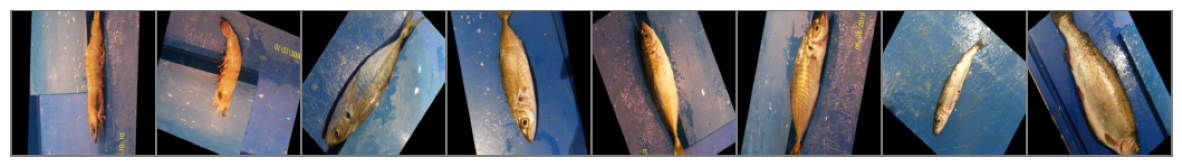

In [10]:
import torchvision

def imshow(img):
    """
    Denormalizes and displays a tensor image.
    
    Reverses the normalization: x_denorm = x * std + mean
    With mean=std=0.5: x_denorm = x * 0.5 + 0.5, mapping [-1,1] → [0,1]
    
    Args:
        img: Image tensor of shape [C, H, W]
    """
    img = img / 2 + 0.5  # Denormalize from [-1,1] to [0,1]
    npimg = img.numpy()
    # PyTorch tensors are in [C, H, W] format, but matplotlib expects [H, W, C]
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')


# Extract one batch from the training DataLoader
dataiter = iter(train_loader)
images, labels_batch = next(dataiter)

# Verify tensor dimensions
print(f"\n=== Batch Shape Verification ===")
print(f"Image batch shape: {images.shape}")
print(f"Expected format: [Batch_Size, Channels, Height, Width]")
print(f"Interpretation: [{batch_size} images, {images.shape[1]} channels (RGB), {images.shape[2]}x{images.shape[3]} pixels]")
print(f"\nLabel batch shape: {labels_batch.shape}")
print(f"Expected format: [Batch_Size]")

# Visualize a grid of images from the batch
plt.figure(figsize=(15, 6))
imshow(torchvision.utils.make_grid(images[:8]))  # Display first 8 images

# Decode integer labels back to class names for display
idx_to_class = {v: k for k, v in class_to_idx.items()}
decoded_labels = [idx_to_class[labels_batch[j].item()] for j in range(8)]
print(f"\nDisplayed labels: {decoded_labels}")
plt.show()

**7. CNN Architecture Design**

Our CNN architecture follows the classical design pattern of convolutional feature extraction followed by fully connected classification layers. The network comprises:

3 Convolutional Blocks: Each block applies convolution → ReLU activation → max pooling

2 Fully Connected Layers: Final classification with dropout regularization

This architecture is inspired by LeNet-5 (LeCun et al., 1998) and VGGNet (Simonyan & Zisserman, 2014), scaled appropriately for our image resolution.

In [11]:
class FishCNN(nn.Module):
    """
    Convolutional Neural Network for fish species classification.
    
    Architecture Summary:
    =====================
    Input: [Batch, 3, 128, 128]
    
    Feature Extraction (Convolutional Layers):
    - Conv Block 1: [3, 128, 128] → [32, 128, 128] → MaxPool → [32, 64, 64]
    - Conv Block 2: [32, 64, 64] → [64, 64, 64] → MaxPool → [64, 32, 32]
    - Conv Block 3: [64, 32, 32] → [128, 32, 32] → MaxPool → [128, 16, 16]
    
    Classification (Fully Connected Layers):
    - Flatten: [128, 16, 16] → [32768]
    - FC1: [32768] → [512] + ReLU + Dropout(0.5)
    - FC2: [512] → [num_classes]
    
    Total Parameters: ~16.8M (depends on num_classes)
    
    Design Rationale:
    - Increasing filter counts (32→64→128) allows learning hierarchical features
    - MaxPooling progressively reduces spatial dimensions (128→64→32→16)
    - Dropout(0.5) prevents overfitting in fully connected layers
    - No activation on final layer (handled by CrossEntropyLoss)
    """
    
    def __init__(self, num_classes):
        super(FishCNN, self).__init__()

        # === CONVOLUTIONAL FEATURE EXTRACTOR ===
        
        # Block 1: Learn low-level features (edges, textures)
        # Conv2d parameters: (in_channels, out_channels, kernel_size, padding)
        # padding=1 with kernel_size=3 maintains spatial dimensions (same padding)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        # Output: [Batch, 32, 128, 128]
        
        # MaxPooling reduces spatial dimensions by factor of 2
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # After pool: [Batch, 32, 64, 64]

        # Block 2: Learn mid-level features (shapes, patterns)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Output: [Batch, 64, 64, 64]
        # After pool: [Batch, 64, 32, 32]

        # Block 3: Learn high-level features (object parts, distinctive markers)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        # Output: [Batch, 128, 32, 32]
        # After pool: [Batch, 128, 16, 16]

        # === FULLY CONNECTED CLASSIFIER ===
        
        # Compute flattened dimension: channels × height × width
        self.flatten_dim = 128 * 16 * 16  # = 32768

        # First dense layer: dimensionality reduction
        self.fc1 = nn.Linear(self.flatten_dim, 512)

        # Dropout: Randomly zeroes 50% of activations during training
        # This prevents co-adaptation of neurons (Srivastava et al., 2014)
        self.dropout = nn.Dropout(0.5)

        # Output layer: one neuron per class
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        """
        Forward propagation through the network.
        
        Args:
            x: Input tensor of shape [Batch, 3, 128, 128]
        
        Returns:
            logits: Raw class scores of shape [Batch, num_classes]
                   (no softmax applied - handled by loss function)
        """
        # Convolutional Block 1: Conv → ReLU → Pool
        # ReLU introduces non-linearity: f(x) = max(0, x)
        x = self.pool(F.relu(self.conv1(x)))
        # Shape: [Batch, 32, 64, 64]

        # Convolutional Block 2
        x = self.pool(F.relu(self.conv2(x)))
        # Shape: [Batch, 64, 32, 32]

        # Convolutional Block 3
        x = self.pool(F.relu(self.conv3(x)))
        # Shape: [Batch, 128, 16, 16]

        # Flatten: Convert 3D feature maps to 1D vector
        # view(-1, N) reshapes to [Batch, N], where -1 infers batch size
        x = x.view(-1, self.flatten_dim)
        # Shape: [Batch, 32768]

        # Fully Connected Layer 1 with dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)  # Only active during training (model.train())
        # Shape: [Batch, 512]

        # Output Layer (no activation - raw logits for CrossEntropyLoss)
        x = self.fc2(x)
        # Shape: [Batch, num_classes]

        return x


# === MODEL INSTANTIATION ===

# Configure device: use GPU if available (significantly faster training)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n=== Hardware Configuration ===")
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Initialize model and move to device
num_classes = len(unique_classes)
model = FishCNN(num_classes=num_classes).to(device)

print(f"\n=== Model Architecture ===")
print(model)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")


=== Hardware Configuration ===
Device: cpu

=== Model Architecture ===
FishCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=32768, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=9, bias=True)
)

Total trainable parameters: 16,875,593


**8. Training Configuration and Optimization**

We employ the Adam optimizer (Kingma & Ba, 2014) with Cross-Entropy loss, which is the standard choice for multi-class classification. The training loop follows the typical PyTorch pattern: forward pass → loss computation → backpropagation → parameter update.

In [12]:
# === HYPERPARAMETER CONFIGURATION ===

# Loss function: Cross-Entropy combines LogSoftmax and NLLLoss
# For K classes: L = -log(exp(y_true) / Σ exp(y_k))
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam (Adaptive Moment Estimation)
# Adam combines advantages of RMSprop and momentum
# Learning rate (α) = 0.001 is a robust default for Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Number of epochs: complete passes through the training dataset
num_epochs = 10


def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    """
    Trains the CNN model with training/validation split evaluation.
    
    Training Process (per epoch):
    1. Forward Pass: Compute predictions and loss
    2. Backward Pass: Compute gradients via backpropagation
    3. Optimization Step: Update weights using gradients
    4. Validation: Evaluate on held-out test set (no gradient computation)
    
    Args:
        model: CNN model to train
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        criterion: Loss function
        optimizer: Optimization algorithm
        num_epochs: Number of training epochs
    
    Returns:
        Tuple of (train_loss, train_acc, val_loss, val_acc) histories
    """
    start_time = time.time()

    # Initialize metric histories for plotting
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    print("\n" + "="*60)
    print("TRAINING COMMENCED")
    print("="*60)

    for epoch in range(num_epochs):
        # === TRAINING PHASE ===
        model.train()  # Enable dropout and batch normalization training mode
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels_batch in train_loader:
            # Move data to device (GPU/CPU)
            inputs = inputs.to(device)
            labels_batch = labels_batch.to(device)

            # Zero the parameter gradients (PyTorch accumulates gradients by default)
            optimizer.zero_grad()

            # Forward pass: compute predictions
            outputs = model(inputs)
            
            # Compute loss
            loss = criterion(outputs, labels_batch)

            # Backward pass: compute gradients via automatic differentiation
            loss.backward()
            
            # Optimization step: update model parameters
            # θ_new = θ_old - α * ∇L(θ)
            optimizer.step()

            # Accumulate statistics for epoch-level metrics
            running_loss += loss.item() * inputs.size(0)  # Multiply by batch size for averaging
            _, preds = torch.max(outputs, 1)  # Get class with highest probability
            running_corrects += torch.sum(preds == labels_batch.data)

        # Compute epoch-level training metrics
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        # === VALIDATION PHASE ===
        model.eval()  # Disable dropout and set batch normalization to inference mode
        val_loss = 0.0
        val_corrects = 0

        # torch.no_grad() disables gradient computation (saves memory and computation)
        with torch.no_grad():
            for inputs, labels_batch in val_loader:
                inputs = inputs.to(device)
                labels_batch = labels_batch.to(device)

                # Forward pass only (no backpropagation)
                outputs = model(inputs)
                loss = criterion(outputs, labels_batch)

                # Accumulate validation statistics
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels_batch.data)

        # Compute epoch-level validation metrics
        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_corrects.double() / len(val_loader.dataset)

        # Record history for visualization
        train_loss_history.append(epoch_loss)
        train_acc_history.append(epoch_acc.item())
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc.item())

        # Print epoch summary
        print(f'Epoch [{epoch+1:2d}/{num_epochs}] | '
              f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    time_elapsed = time.time() - start_time
    print("\n" + "="*60)
    print(f'TRAINING COMPLETED in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print("="*60)

    return train_loss_history, train_acc_history, val_loss_history, val_acc_history


# === INITIATE TRAINING ===
history = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=num_epochs)

# Unpack training history
train_loss, train_acc, val_loss, val_acc = history


TRAINING COMMENCED
Epoch [ 1/10] | Train Loss: 1.1524 Acc: 0.5744 | Val Loss: 0.4083 Acc: 0.8650
Epoch [ 2/10] | Train Loss: 0.3357 Acc: 0.8808 | Val Loss: 0.1470 Acc: 0.9506
Epoch [ 3/10] | Train Loss: 0.1473 Acc: 0.9503 | Val Loss: 0.1792 Acc: 0.9350
Epoch [ 4/10] | Train Loss: 0.1044 Acc: 0.9628 | Val Loss: 0.0405 Acc: 0.9861
Epoch [ 5/10] | Train Loss: 0.0692 Acc: 0.9767 | Val Loss: 0.0529 Acc: 0.9783
Epoch [ 6/10] | Train Loss: 0.0598 Acc: 0.9801 | Val Loss: 0.0391 Acc: 0.9839
Epoch [ 7/10] | Train Loss: 0.0431 Acc: 0.9846 | Val Loss: 0.0164 Acc: 0.9956
Epoch [ 8/10] | Train Loss: 0.0441 Acc: 0.9844 | Val Loss: 0.0256 Acc: 0.9922
Epoch [ 9/10] | Train Loss: 0.0301 Acc: 0.9883 | Val Loss: 0.0779 Acc: 0.9744
Epoch [10/10] | Train Loss: 0.0547 Acc: 0.9829 | Val Loss: 0.0124 Acc: 0.9961

TRAINING COMPLETED in 13m 37s


**9. Training Dynamics Visualization**

Monitoring loss and accuracy curves is essential for diagnosing training behavior. These plots reveal whether the model is learning effectively, overfitting, or requires hyperparameter adjustment.

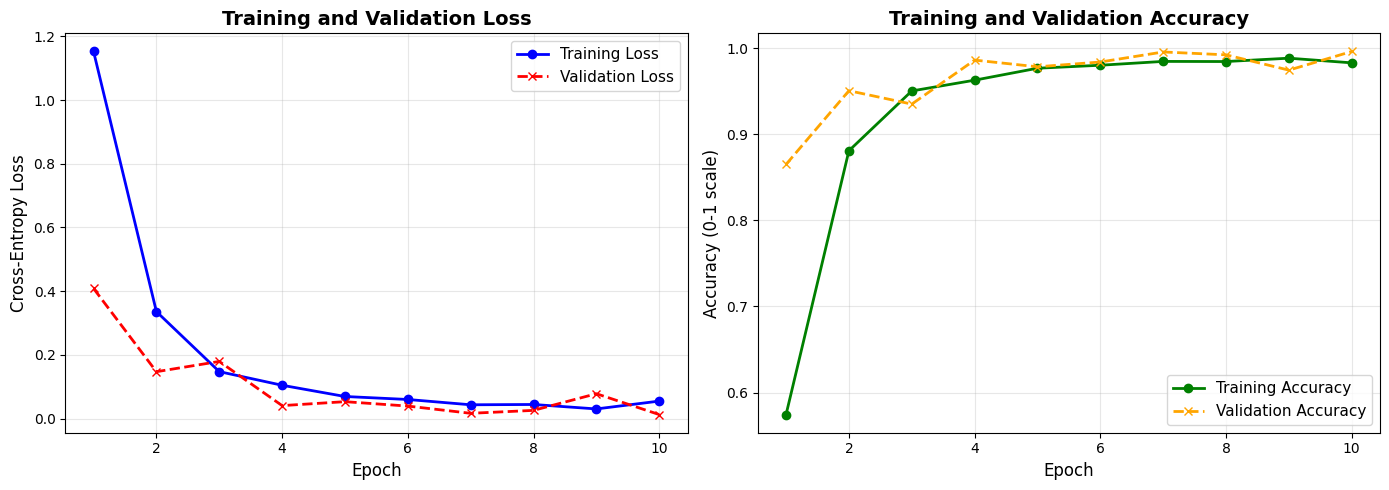


=== Final Performance Summary ===
Training Accuracy:   0.9829 (98.29%)
Validation Accuracy: 0.9961 (99.61%)
Generalization Gap:  -0.0132 (-1.32%)


In [13]:
# Extract training history
train_loss, train_acc, val_loss, val_acc = history

# Create dual-panel visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# === PANEL 1: LOSS CURVES ===
ax1.plot(range(1, num_epochs+1), train_loss, label='Training Loss', 
         color='blue', marker='o', linewidth=2, markersize=6)
ax1.plot(range(1, num_epochs+1), val_loss, label='Validation Loss', 
         color='red', linestyle='--', marker='x', linewidth=2, markersize=6)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Interpretation notes:
# - Decreasing train loss: Model is learning
# - Val loss >> train loss: Overfitting (model memorizing training data)
# - Increasing val loss after epoch N: Training should stop at epoch N (early stopping)

# === PANEL 2: ACCURACY CURVES ===
ax2.plot(range(1, num_epochs+1), train_acc, label='Training Accuracy', 
         color='green', marker='o', linewidth=2, markersize=6)
ax2.plot(range(1, num_epochs+1), val_acc, label='Validation Accuracy', 
         color='orange', linestyle='--', marker='x', linewidth=2, markersize=6)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (0-1 scale)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Interpretation notes:
# - Gap between curves: Degree of overfitting
# - Plateauing: Model has converged (may need more capacity or data)
# - Oscillating val accuracy: Learning rate may be too high

plt.tight_layout()
plt.show()

# Print final performance summary
print("\n=== Final Performance Summary ===")
print(f"Training Accuracy:   {train_acc[-1]:.4f} ({train_acc[-1]*100:.2f}%)")
print(f"Validation Accuracy: {val_acc[-1]:.4f} ({val_acc[-1]*100:.2f}%)")
print(f"Generalization Gap:  {(train_acc[-1] - val_acc[-1]):.4f} ({(train_acc[-1] - val_acc[-1])*100:.2f}%)")

**10. Confusion Matrix Analysis**

The confusion matrix provides a detailed breakdown of classification performance across all classes, revealing which fish species are frequently confused by the model.


=== Generating Confusion Matrix ===


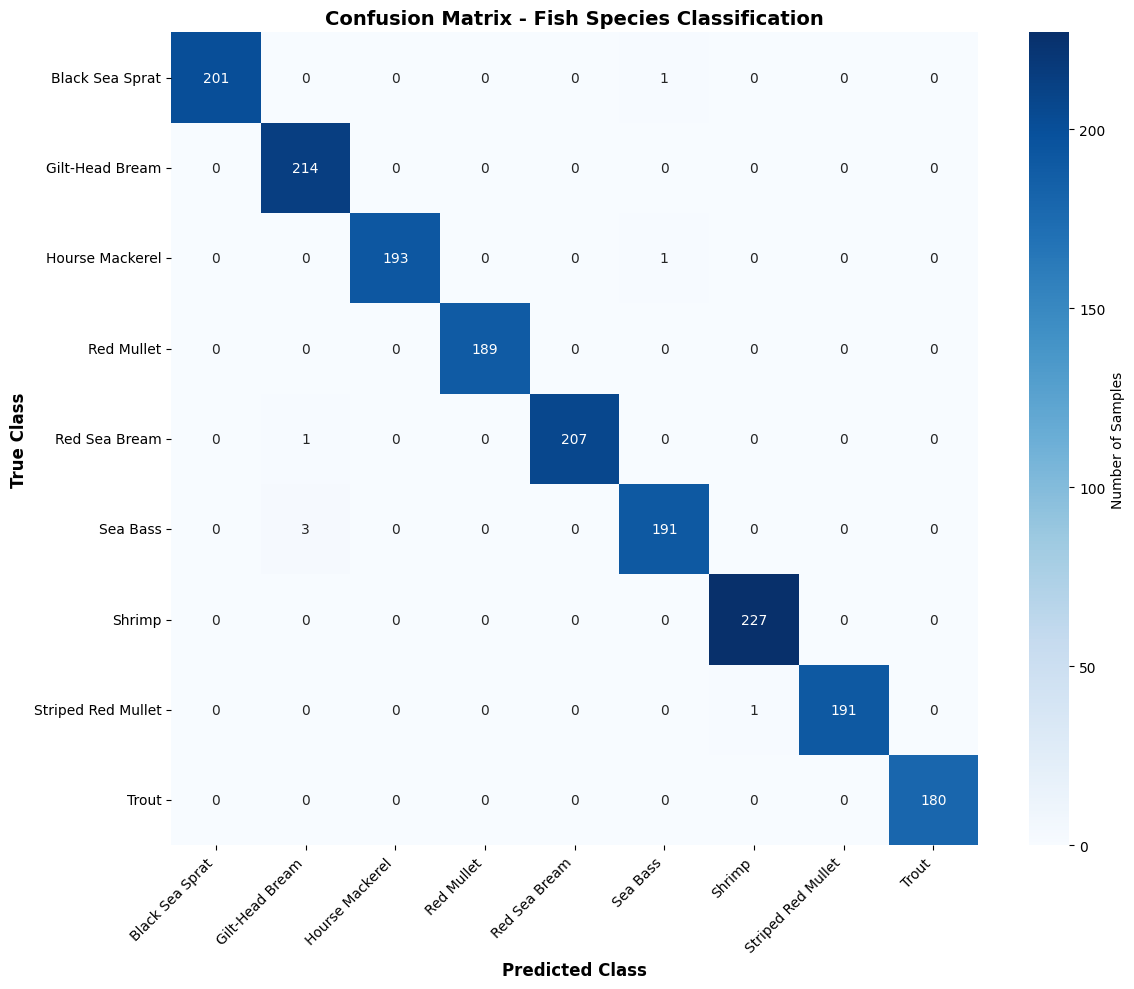


=== Per-Class Performance Metrics ===
Class                     Precision    Recall       F1-Score    
-----------------------------------------------------------------
Black Sea Sprat           1.0000       0.9950       0.9975      
Gilt-Head Bream           0.9817       1.0000       0.9907      
Hourse Mackerel           1.0000       0.9948       0.9974      
Red Mullet                1.0000       1.0000       1.0000      
Red Sea Bream             1.0000       0.9952       0.9976      
Sea Bass                  0.9896       0.9845       0.9871      
Shrimp                    0.9956       1.0000       0.9978      
Striped Red Mullet        1.0000       0.9948       0.9974      
Trout                     1.0000       1.0000       1.0000      

Overall Accuracy          0.9961 (99.61%)


In [14]:
# === GENERATE PREDICTIONS ON TEST SET ===

y_pred = []  # Predicted labels
y_true = []  # Ground truth labels

model.eval()  # Set to evaluation mode

print("\n=== Generating Confusion Matrix ===")
with torch.no_grad():
    for inputs, labels_batch in test_loader:
        inputs = inputs.to(device)
        
        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        # Collect predictions and ground truth (move to CPU for sklearn)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels_batch.cpu().numpy())

# === COMPUTE CONFUSION MATRIX ===
# Confusion Matrix: CM[i,j] = number of samples with true label i predicted as j
# Diagonal elements: Correct classifications
# Off-diagonal elements: Misclassifications

class_names = [k for k, v in sorted(class_to_idx.items(), key=lambda item: item[1])]
cm = confusion_matrix(y_true, y_pred)

# === VISUALIZE WITH HEATMAP ===
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Number of Samples'})

plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('True Class', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Fish Species Classification', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# === COMPUTE PER-CLASS METRICS ===
print("\n=== Per-Class Performance Metrics ===")
print(f"{'Class':<25} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 65)

for i, class_name in enumerate(class_names):
    # True Positives: correctly predicted as this class
    tp = cm[i, i]
    
    # False Positives: incorrectly predicted as this class
    fp = cm[:, i].sum() - tp
    
    # False Negatives: this class incorrectly predicted as another
    fn = cm[i, :].sum() - tp
    
    # Precision: Of all predicted as this class, how many were correct?
    # P = TP / (TP + FP)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    # Recall (Sensitivity): Of all true instances, how many were detected?
    # R = TP / (TP + FN)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # F1-Score: Harmonic mean of precision and recall
    # F1 = 2 * (P * R) / (P + R)
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"{class_name:<25} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f}")
overall_accuracy = np.trace(cm) / np.sum(cm)
print(f"\n{'Overall Accuracy':<25} {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")